In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('IPL_Squad_2023_Auction_Dataset.csv')
df.head()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [3]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)
df.head()

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [4]:
costliest=df.groupby("Player's List")['COST IN ₹ (CR.)'].sum().sort_values(ascending=False).head()
print(costliest)

Player's List
Sam Curran         18.50
Cameron Green      17.50
Ben Stokes         16.25
Nicholas Pooran    16.00
Harry Brook        13.25
Name: COST IN ₹ (CR.), dtype: float64


In [5]:
df_sold = df[df['COST IN ₹ (CR.)'] > 0]
min_cost = df_sold['COST IN ₹ (CR.)'].min()
cheapest_players = df_sold[df_sold['COST IN ₹ (CR.)'] == min_cost][["Player's List", "Team", "COST IN ₹ (CR.)"]]
print(cheapest_players)


          Player's List                        Team  COST IN ₹ (CR.)
6           Urvil Patel              Gujarat Titans              0.2
29        Bhagath Varma         Chennai Super Kings              0.2
30          Ajay Mandal         Chennai Super Kings              0.2
31        Shaik Rasheed         Chennai Super Kings              0.2
81   Kulwant Khejroliya       Kolkata Knight Riders              0.2
82        Suyash Sharma       Kolkata Knight Riders              0.2
100        Mohit Rathee          Punjab Super Kings              0.2
101   Vidwath Kaverappa          Punjab Super Kings              0.2
102        Shivam Singh          Punjab Super Kings              0.2
126       Swapnil Singh        Lucknow Super Giants              0.2
127      Yudhvir Charak        Lucknow Super Giants              0.2
128       Prerak Mankad        Lucknow Super Giants              0.2
147        Raghav Goyal              Mumbai Indians              0.2
148        Shams Mulani           

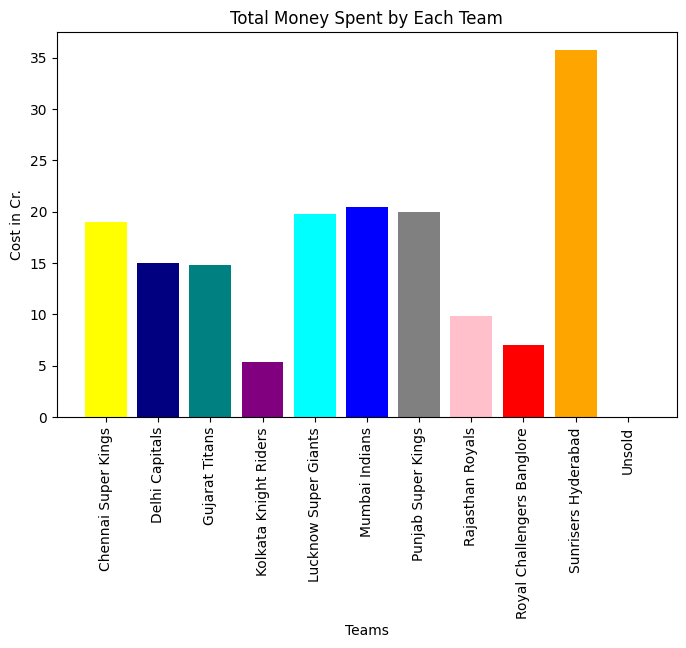

In [6]:
money_spent = df.groupby('Team')['COST IN ₹ (CR.)'].sum()
team_colors = {
    'Chennai Super Kings': 'yellow',
    'Mumbai Indians': 'blue',
    'Royal Challengers Banglore': 'red',
    'Kolkata Knight Riders': 'purple',
    'Rajasthan Royals': 'pink',
    'Sunrisers Hyderabad': 'orange',
    'Delhi Capitals': 'navy',
    'Punjab Super King': 'maroon',
    'Gujarat Titans': 'teal',
    'Lucknow Super Giants': 'cyan'
}
colors = [team_colors.get(team, 'grey') for team in money_spent.index]


plt.figure(figsize=(8,5))
plt.bar(money_spent.index, money_spent.values,color=colors)
plt.xlabel("Teams")
plt.ylabel("Cost in Cr.")
plt.title("Total Money Spent by Each Team")
plt.xticks(rotation=90)
plt.show()


In [7]:
unsold_bowlers=df[(df['TYPE']=='BOWLER') & (df['Team']=='Unsold') ].shape[0]
unsold_bowlers


104

In [8]:
unsold_players=df[(df['Team']=='Unsold') ].shape[0]
unsold_players

325

In [9]:
unsold = df[df['Team'] == 'Unsold']
type_unsold = unsold.groupby('TYPE').size()
print(type_unsold)

TYPE
ALL-ROUNDER     126
BATSMAN          50
BOWLER          104
WICKETKEEPER     45
dtype: int64


In [10]:
gt=df[df['Team']=='Gujarat Titans']
new_players=gt[df['2022 Squad']!='GT']
new_players['Player\'s List']

C:\Users\omdon\AppData\Local\Temp\ipykernel_10852\2100322021.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_players=gt[df['2022 Squad']!='GT']


0        Shivam Mavi
1      Joshua Little
2    Kane Williamson
3        K.S. Bharat
4       Mohit Sharma
5        Odean Smith
6        Urvil Patel
Name: Player's List, dtype: str

<BarContainer object of 4 artists>

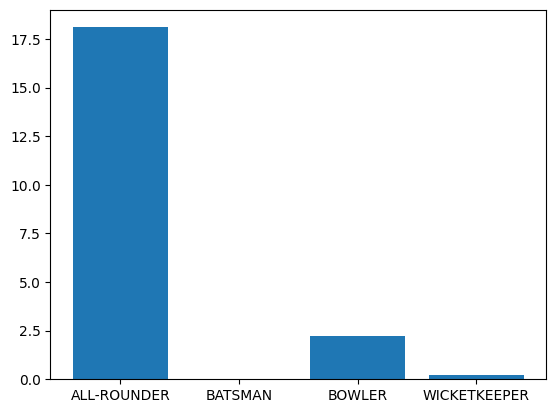

In [11]:
mi=df[df['Team']=='Mumbai Indians']
money_spent=mi.groupby('TYPE')['COST IN ₹ (CR.)'].sum()
money_spent

plt.bar(money_spent.index, money_spent.values)

<BarContainer object of 4 artists>

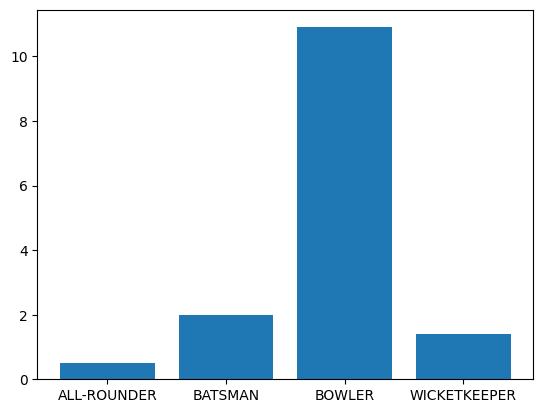

In [12]:
gt=df[df['Team']=='Gujarat Titans']
money_spent=gt.groupby('TYPE')['COST IN ₹ (CR.)'].sum()
money_spent

plt.bar(money_spent.index, money_spent.values)